In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import spectroscopic_efficiency

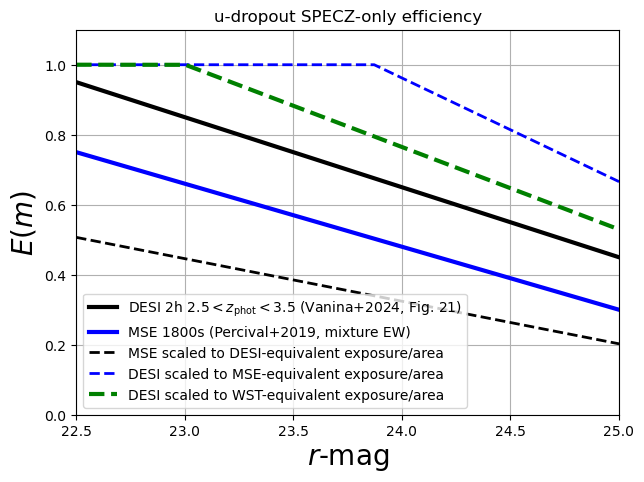

In [2]:
# Magnitude range
m_vals = np.linspace(22., 26, 3400)

def E_mse_udrop_single_exp(m): 
    return np.minimum(np.maximum((-0.18*m + 4.8), 0), 1)
def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)
    #return np.maximum(0.8 - 0.01*(m-24),0)


tMSE = 1800 #MSE time
SMSE = 11.25**2
tDESI= 2 * 60 * 60 #Dark time WST
SDESI = 3.8**2 #Surface of MSE mirror
alpha_MSE_to_DESI = np.sqrt(tDESI * SDESI)/np.sqrt(tMSE * SMSE)



alpha_DESI_to_WST = np.sqrt(1000 * 12**2)/np.sqrt(tDESI * SDESI)
plt.figure(figsize=(7,5))
plt.title('u-dropout SPECZ-only efficiency')
plt.plot(m_vals, E_desi_udrop_single_exp(m_vals), 'k',  lw=3, label = r'DESI 2h $2.5 < z_{\rm phot} < 3.5$ (Vanina+2024, Fig. 21)')
plt.plot(m_vals, E_mse_udrop_single_exp(m_vals), 'b',  lw=3, label = 'MSE 1800s (Percival+2019, mixture EW)')

plt.plot(m_vals, E_mse_udrop_single_exp(m_vals) * alpha_MSE_to_DESI, '--k', lw=2, label = r'MSE scaled to DESI-equivalent exposure/area')


plt.plot(m_vals, np.minimum(E_desi_udrop_single_exp(m_vals)/ alpha_MSE_to_DESI, 1), '--b', lw=2,  label = r'DESI scaled to MSE-equivalent exposure/area')

plt.plot(m_vals, np.minimum(E_desi_udrop_single_exp(m_vals) * alpha_DESI_to_WST, 1), '--g', lw=3,  label = r'DESI scaled to WST-equivalent exposure/area')

#multiplied by $\sqrt{t_{\rm DESI}/t_{\rm MSE}}\times\sqrt{S_{\rm DESI}/S_{\rm MSE}}
plt.legend(ncols=1)
plt.xlabel(r'$r$-mag', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)
plt.xlim(22.5, 25)
plt.ylim(0, 1.1)
plt.grid()

In [3]:
alpha_MSE_to_DESI

np.float64(0.6755555555555556)

In [4]:
(np.sqrt(SMSE)/np.sqrt(SDESI))*np.sqrt(tMSE)/np.sqrt(tDESI)

np.float64(1.480263157894737)